In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [127]:
df = pd.read_csv('../Data/processed/Gurgaon_cleaned_final_1.csv')
df.head()

,property_type,sector,price,area,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,7.0,0.45,900.0,2,2,1,4.0,Relatively New,1066.350711,0,0,0,0,0,2,28
1,flat,5.0,0.50,650.0,2,2,1,1.0,Old Property,770.142180,0,0,0,0,0,0,37
2,flat,48.0,0.40,595.0,2,2,3,12.0,New Property,704.976303,0,0,0,0,0,2,36
3,flat,61.0,1.47,1200.0,2,2,2,2.0,Under Construction,1421.800948,1,0,0,0,0,2,76
4,flat,92.0,0.70,1345.0,2,2,3,5.0,Under Construction,1185.022026,1,0,0,0,0,2,0


In [128]:
df = pd.get_dummies(df, columns=['property_type','agePossession'], drop_first=True)

In [129]:
df.shape

(3853, 20)

In [130]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [131]:
df.luxury_score = df.luxury_score.apply(categorize_luxury)

In [132]:
df.drop(columns=['area'], inplace=True, errors='ignore')

In [133]:
df = pd.get_dummies(df, columns=['luxury_score'], drop_first=True)

In [134]:
X = df.drop(columns=['price'])
y = df['price']

<Axes: >

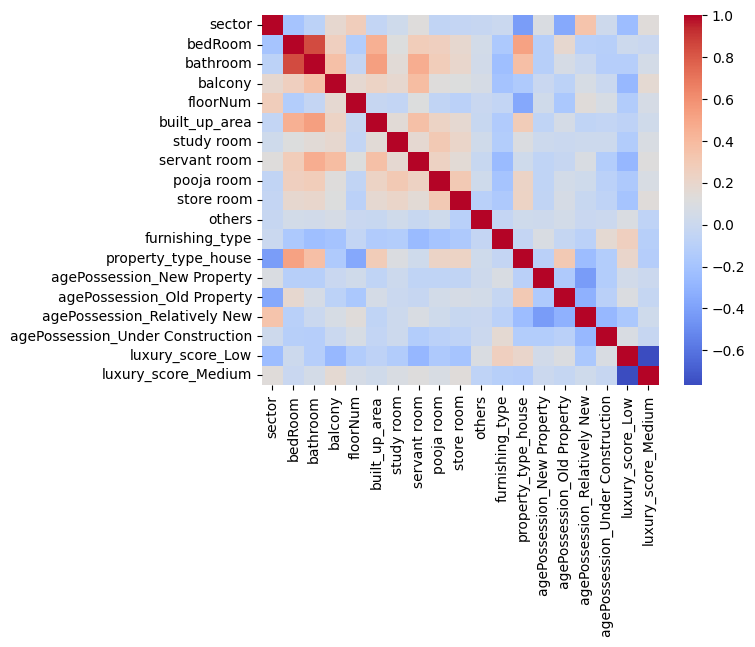

In [135]:
sns.heatmap(X.corr(),  cmap='coolwarm')

In [136]:
fi_df1 = df.corr()['price'].drop('price').to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.145414
1,bedRoom,0.510436
2,bathroom,0.597322
3,balcony,0.228798
4,floorNum,-0.073250
5,built_up_area,0.686357
6,study room,0.242169
7,servant room,0.397470
8,pooja room,0.317852
9,store room,0.300818


# Using Random Forest Technique

In [137]:
X.head()

,sector,bedRoom,bathroom,balcony,floorNum,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,property_type_house,agePossession_New Property,agePossession_Old Property,agePossession_Relatively New,agePossession_Under Construction,luxury_score_Low,luxury_score_Medium
0,7.0,2,2,1,4.0,1066.350711,0,0,0,0,0,2,False,False,False,True,False,True,False
1,5.0,2,2,1,1.0,770.142180,0,0,0,0,0,0,False,False,True,False,False,True,False
2,48.0,2,2,3,12.0,704.976303,0,0,0,0,0,2,False,True,False,False,False,True,False
3,61.0,2,2,2,2.0,1421.800948,1,0,0,0,0,2,False,False,False,False,True,False,True
4,92.0,2,2,3,5.0,1185.022026,1,0,0,0,0,2,False,False,False,False,True,True,False


In [138]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract features importancee

fi_df2 = pd.DataFrame({'feature': X.columns, 'RF_Importance': rf.feature_importances_}).sort_values(by='RF_Importance', ascending=False)
fi_df2


,feature,RF_Importance
5,built_up_area,0.605235
0,sector,0.123296
12,property_type_house,0.082687
2,bathroom,0.042541
7,servant room,0.027606
4,floorNum,0.027293
1,bedRoom,0.024743
11,furnishing_type,0.008352
3,balcony,0.007787
9,store room,0.007182


# Gradient boosting technique

In [139]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X, y)

# Extract features importancee

fi_df3 = pd.DataFrame({'feature': X.columns, 'gb_Importance': gb.feature_importances_}).sort_values(by='gb_Importance', ascending=False)
fi_df3

,feature,gb_Importance
5,built_up_area,0.642734
0,sector,0.123601
12,property_type_house,0.081324
2,bathroom,0.064295
1,bedRoom,0.025545
7,servant room,0.024421
4,floorNum,0.014528
9,store room,0.008050
18,luxury_score_Medium,0.002974
3,balcony,0.002955


# Permutaion Technique

In [140]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train, y_train)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test, y_test, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
5,built_up_area,0.626707
12,property_type_house,0.152296
0,sector,0.133632
2,bathroom,0.025495
7,servant room,0.019395
4,floorNum,0.013236
1,bedRoom,0.009671
18,luxury_score_Medium,0.009361
15,agePossession_Relatively New,0.005034
17,luxury_score_Low,0.004605


# Lasso

In [141]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
5,built_up_area,1.207369
2,bathroom,0.696296
12,property_type_house,0.652440
7,servant room,0.230020
9,store room,0.224468
6,study room,0.177569
8,pooja room,0.095966
16,agePossession_Under Construction,0.093073
3,balcony,0.063170
4,floorNum,0.053623


# Technique RFE

In [142]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X.shape[1], step=1)
selector_label = selector_label.fit(X, y)

# Get the selected features based on RFE
selected_features = X.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
5,built_up_area,0.597748
0,sector,0.123522
12,property_type_house,0.086500
2,bathroom,0.042913
1,bedRoom,0.028382
7,servant room,0.027049
4,floorNum,0.025675
11,furnishing_type,0.008347
3,balcony,0.007482
9,store room,0.007000


# Linear Regression Weights

In [143]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
5,built_up_area,1.208306
2,bathroom,0.761970
12,property_type_house,0.684882
7,servant room,0.232078
9,store room,0.228762
6,study room,0.180166
16,agePossession_Under Construction,0.112069
8,pooja room,0.102537
18,luxury_score_Medium,0.081210
3,balcony,0.076880


# Shap

In [144]:
!pip install shap

In [147]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)


In [ ]:
shap_values
fi_df8 = pd.DataFrame({
    'feature': X.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
5,built_up_area,1.180647
0,sector,0.402817
12,property_type_house,0.392312
2,bathroom,0.231387
7,servant room,0.124093
4,floorNum,0.065826
1,bedRoom,0.050466
3,balcony,0.039825
11,furnishing_type,0.035386
6,study room,0.017960


In [146]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')
final_fi_df

,corr_coeff,RF_Importance,gb_Importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.145414,0.123296,0.123601,0.133632,-0.117228,0.123522,-0.136037,0.402817
bedRoom,0.510436,0.024743,0.025545,0.009671,-0.266471,0.028382,-0.352428,0.050466
bathroom,0.597322,0.042541,0.064295,0.025495,0.696296,0.042913,0.761970,0.231387
balcony,0.228798,0.007787,0.002955,0.001974,0.063170,0.007482,0.076880,0.039825
floorNum,-0.073250,0.027293,0.014528,0.013236,0.053623,0.025675,0.067902,0.065826
built_up_area,0.686357,0.605235,0.642734,0.626707,1.207369,0.597748,1.208306,1.180647
study room,0.242169,0.006944,0.002615,-0.000255,0.177569,0.006065,0.180166,0.017960
servant room,0.397470,0.027606,0.024421,0.019395,0.230020,0.027049,0.232078,0.124093
pooja room,0.317852,0.003902,0.000000,-0.002895,0.095966,0.004087,0.102537,0.006250


In [153]:
# Normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [155]:
final_fi_df[['gb_Importance', 'lasso_coeff', 'permutation_importance', 'rfe_score', 'reg_coeffs', 'SHAP_score','RF_Importance']].mean(axis = 1).sort_values(ascending=False)    

feature
built_up_area                       0.529055
property_type_house                 0.140822
bathroom                            0.105254
sector                              0.082029
servant room                        0.042256
store room                          0.025496
floorNum                            0.020726
study room                          0.019788
balcony                             0.011537
agePossession_Under Construction    0.010486
pooja room                          0.010284
luxury_score_Medium                 0.009698
agePossession_New Property          0.007345
luxury_score_Low                    0.004894
agePossession_Relatively New        0.004425
agePossession_Old Property          0.000486
others                             -0.001904
furnishing_type                    -0.009374
bedRoom                            -0.013304
dtype: float64

# With all columns, we can see that the top features are 'built_up_area', 'property_type_house', 'bathroom','sector', and 'agePossession'. 
# These features have the highest average importance across all methods, indicating that they are likely to be the most influential in predicting house prices in Gurgaon.

In [157]:
# with all columns
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R^2 scores:", scores)
print("scores mean:", scores.mean())


Cross-validated R^2 scores: [0.74086863 0.77483904 0.83325092 0.85791716 0.64324296]
scores mean: 0.7700237401652569


In [159]:
# with dropped columns like others, furnishing type and bedroom.
rf_dropped = RandomForestRegressor(n_estimators=100, random_state=42)
X_dropped = X.drop(columns=['others'], errors='ignore')
scores_dropped = cross_val_score(rf_dropped, X_dropped, y, cv=5, scoring='r2')
print("Cross-validated R^2 scores (dropped columns):", scores_dropped)
print("Dropped columns R^2 scores mean:", scores_dropped.mean())

Cross-validated R^2 scores (dropped columns): [0.74262709 0.7777544  0.83604351 0.85965134 0.64093543]
Dropped columns R^2 scores mean: 0.7714023542231665
